In [1]:
# Install if not already
# pip install osmnx networkx

import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fetch the drivable road network for Hohhot city center
# This downloads from OpenStreetMap — needs internet connection
print("Fetching Hohhot road network from OpenStreetMap...")
G = ox.graph_from_place(
    "Hohhot, Inner Mongolia, China",
    network_type="drive",
    retain_all=False
)
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

Fetching Hohhot road network from OpenStreetMap...
Nodes: 15610
Edges: 37293


In [2]:
# These are the real road names in Hohhot
# OSMnx will geocode them to GPS coordinates
camera_locations = {
    'A.Zhandong Road':        '展东路, 呼和浩特',   # Zhandong Road
    'B.Dongying Road':        '东营路, 呼和浩特',   # Dongying Road
    'C.Ulanqab East Street':  '乌兰察布东街, 呼和浩特',
    "D.Xing'an South Road":   '兴安南路, 呼和浩特',  # Xing'an South Road
    "E.People's Hall":        '人民会堂, 呼和浩特',  # People's Hall
    'F.South intersection':   '南二环, 呼和浩特',    # South intersection
    'G.Xinhua Square':        '新华广场, 呼和浩特',  # Xinhua Square
    'H.Zhongshan Road':       '中山路, 呼和浩特',    # Zhongshan Road
}

# Geocode each location to GPS coordinates
print("Geocoding camera locations...")
coords = {}
failed = []

for name, query in camera_locations.items():
    try:
        loc = ox.geocode(query)
        coords[name] = (loc[0], loc[1])  # (lat, lon)
        print(f"  ✅ {name}: {loc[0]:.4f}, {loc[1]:.4f}")
    except Exception as e:
        print(f"  ⚠️  {name}: geocoding failed — {e}")
        failed.append(name)

print(f"\nSuccessfully geocoded: {len(coords)}/{len(camera_locations)}")

Geocoding camera locations...
  ✅ A.Zhandong Road: 40.8388, 111.7110
  ✅ B.Dongying Road: 40.8295, 111.7019
  ✅ C.Ulanqab East Street: 40.8247, 111.7164
  ✅ D.Xing'an South Road: 40.7973, 111.7064
  ✅ E.People's Hall: 40.8220, 111.6696
  ✅ F.South intersection: 40.8063, 111.7418
  ✅ G.Xinhua Square: 40.8202, 111.6610
  ✅ H.Zhongshan Road: 40.8141, 111.6640

Successfully geocoded: 8/8


In [ ]:
# Manual GPS coordinates for any that failed
# These are approximate centers of each road/landmark in Hohhot
manual_coords = {
    'A.Zhandong Road1':        (34.735139, 111.257501),
    'A.Zhandong Road2':        (34.735139, 111.257501),
    'B.Dongying Road1':        (40.834035, 111.707467),
    'B.Dongying Road2':        (40.834035, 111.707467),
    'C.Ulanqab East Street1':  (40.918589, 112.603652),
    'C.Ulanqab East Street2':  (40.918589, 112.603652),
    'C.Ulanqab East Street3':  (40.918589, 112.603652),
    'C.Ulanqab East Street4':  (40.918589, 112.603652),
    "D.Xing'an South Road1":   (40.809241, 111.708249),
    "D.Xing'an South Road2":   (40.809241, 111.708249),
    "E.People's Hall1":        (40.117054, 114.168663),
    "E.People's Hall2":        (40.117054, 114.168663),
    'F.South intersection1':   (39.871379, 116.461249),
    'F.South intersection2':   (39.871379, 116.461249),
    'G.Xinhua Square1':        (40.8134, 111.6889),
    'G.Xinhua Square2':        (40.8141, 111.6901),
    'H.Zhongshan Road1':       (40.8223, 111.7089),
    'H.Zhongshan Road2':       (40.8236, 111.7102),
}

# Fill in any failed geocodes with manual coords
for name in failed:
    coords[name] = manual_coords[name]
    print(f"Using manual coords for {name}: {manual_coords[name]}")

print(f"\nFinal coords for all {len(coords)} locations ready")

In [3]:
# Find the nearest road network node for each camera location
print("Snapping cameras to nearest road network nodes...")

camera_nodes = {}
for name, (lat, lon) in coords.items():
    try:
        node = ox.nearest_nodes(G, lon, lat)  # note: osmnx takes (lon, lat)
        camera_nodes[name] = node
        print(f"  {name} → node {node}")
    except Exception as e:
        print(f"  ⚠️  {name}: snap failed — {e}")

print(f"\nSnapped {len(camera_nodes)} cameras to road network nodes")

Snapping cameras to nearest road network nodes...
  A.Zhandong Road → node 7769993529
  B.Dongying Road → node 1444390372
  C.Ulanqab East Street → node 1496230903
  D.Xing'an South Road → node 5787833638
  E.People's Hall → node 1444390268
  F.South intersection → node 1624721392
  G.Xinhua Square → node 3909145233
  H.Zhongshan Road → node 1487146189

Snapped 8 cameras to road network nodes


In [5]:
sources = sorted(camera_nodes.keys())
n = len(sources)

# Distance matrix — shortest path distance between each pair
print("Computing shortest path distances between all camera pairs...")

dist_matrix = np.full((n, n), np.inf)

for i, src_i in enumerate(sources):
    for j, src_j in enumerate(sources):
        if i == j:
            dist_matrix[i, j] = 0
            continue
        try:
            dist = nx.shortest_path_length(
                G,
                camera_nodes[src_i],
                camera_nodes[src_j],
                weight='length'   # length in meters
            )
            dist_matrix[i, j] = dist
        except nx.NetworkXNoPath:
            dist_matrix[i, j] = np.inf

print("Distance matrix computed")
print(f"Max finite distance: {dist_matrix[dist_matrix != np.inf].max():.0f} meters")
print(f"Min non-zero distance: {dist_matrix[dist_matrix > 0].min():.0f} meters")

# Convert distances to adjacency weights using Gaussian kernel
# Closer roads → stronger connection
# σ (sigma) controls how fast weight decays with distance
sigma = dist_matrix[dist_matrix > 0].std()

adj_matrix = np.exp(-(dist_matrix ** 2) / (2 * sigma ** 2))
adj_matrix[dist_matrix == np.inf] = 0  # no path = no connection
np.fill_diagonal(adj_matrix, 0)         # no self-loops

print(f"\nAdjacency matrix shape: {adj_matrix.shape}")
print(f"Sigma used: {sigma:.0f} meters")
print(f"Weight range: {adj_matrix[adj_matrix > 0].min():.4f} to {adj_matrix.max():.4f}")

Computing shortest path distances between all camera pairs...
Distance matrix computed
Max finite distance: 8840 meters
Min non-zero distance: 782 meters

Adjacency matrix shape: (8, 8)
Sigma used: 2172 meters
Weight range: 0.0003 to 0.9372


In [6]:
# Only keep edges where weight is above a threshold
# This removes spurious connections between far-apart locations
THRESHOLD = 0.1  # adjust based on your distance distribution

adj_binary = (adj_matrix > THRESHOLD).astype(float)
adj_weighted = adj_matrix * adj_binary

print("Adjacency matrix after thresholding:")
print(f"  Total possible edges: {n*(n-1)}")
print(f"  Edges kept: {int(adj_binary.sum())}")
print(f"  Avg connections per node: {adj_binary.sum(axis=1).mean():.1f}")
print()

# Show which locations connect to which
print("Connection map:")
for i, src in enumerate(sources):
    connected = [sources[j] for j in range(n) if adj_binary[i,j] > 0]
    print(f"  {src}")
    for c in connected:
        print(f"    → {c}  (weight={adj_weighted[i, sources.index(c)]:.3f})")

Adjacency matrix after thresholding:
  Total possible edges: 56
  Edges kept: 26
  Avg connections per node: 3.2

Connection map:
  A.Zhandong Road
    → B.Dongying Road  (weight=0.700)
    → C.Ulanqab East Street  (weight=0.744)
    → E.People's Hall  (weight=0.111)
  B.Dongying Road
    → A.Zhandong Road  (weight=0.716)
    → C.Ulanqab East Street  (weight=0.690)
    → E.People's Hall  (weight=0.422)
    → G.Xinhua Square  (weight=0.246)
    → H.Zhongshan Road  (weight=0.141)
  C.Ulanqab East Street
    → A.Zhandong Road  (weight=0.760)
    → B.Dongying Road  (weight=0.690)
    → F.South intersection  (weight=0.206)
  D.Xing'an South Road
    → B.Dongying Road  (weight=0.154)
    → C.Ulanqab East Street  (weight=0.134)
    → F.South intersection  (weight=0.236)
  E.People's Hall
    → A.Zhandong Road  (weight=0.117)
    → B.Dongying Road  (weight=0.417)
    → G.Xinhua Square  (weight=0.937)
    → H.Zhongshan Road  (weight=0.770)
  F.South intersection
    → C.Ulanqab East Street  (we

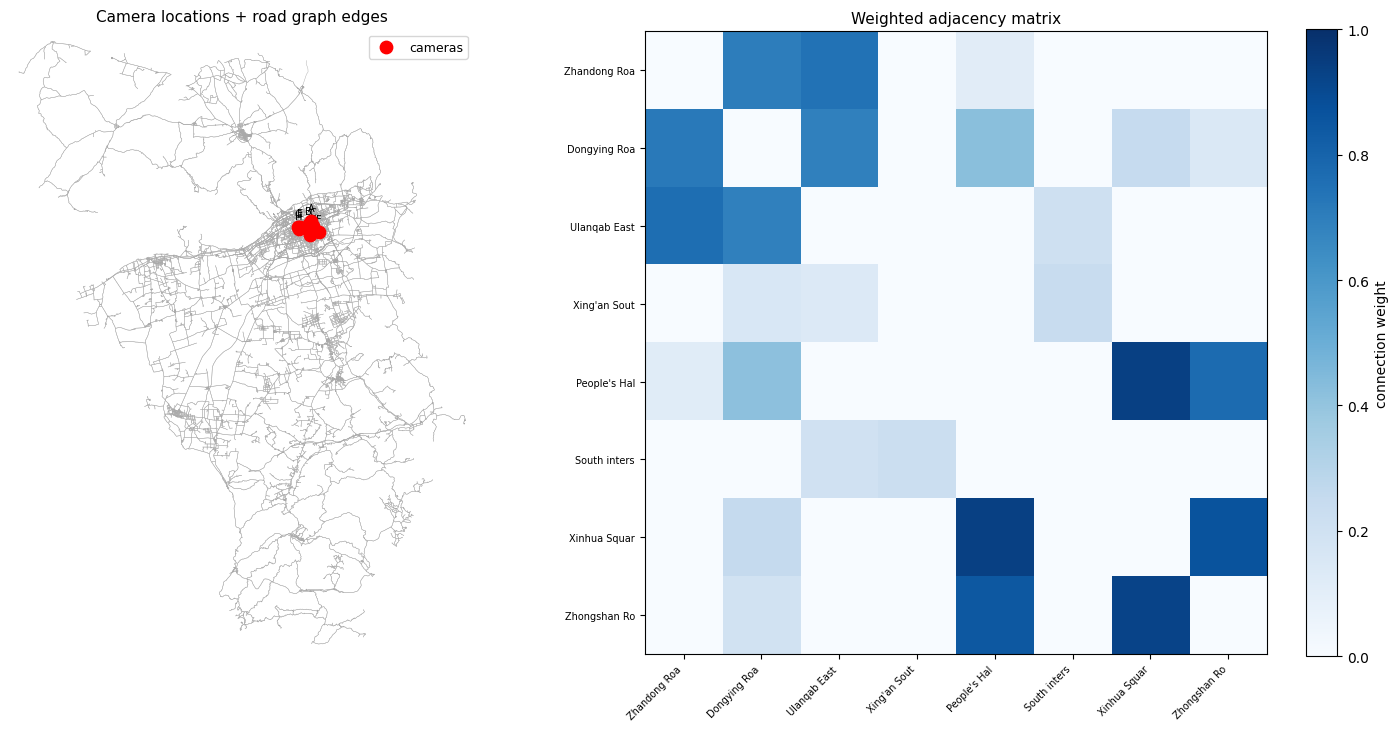


Saved adjacency_matrix.npy and adjacency_matrix.csv
Load later with: adj = np.load('../data/adjacency_matrix.npy')


In [9]:
# Plot the road network with camera locations
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — map view
ax1 = axes[0]
ox.plot_graph(G, ax=ax1, node_size=0, edge_linewidth=0.3,
              edge_color='#aaaaaa', bgcolor='white', show=False)

# Plot camera locations
lats = [coords[s][0] for s in sources]
lons = [coords[s][1] for s in sources]
ax1.scatter(lons, lats, c='red', s=80, zorder=5, label='cameras')
for i, src in enumerate(sources):
    ax1.annotate(src.split('.')[0],
                 (lons[i], lats[i]),
                 fontsize=7, ha='center', va='bottom',
                 xytext=(0, 6), textcoords='offset points')

# Draw edges
for i in range(n):
    for j in range(i+1, n):
        if adj_binary[i, j] > 0:
            ax1.plot([lons[i], lons[j]], [lats[i], lats[j]],
                     'b-', alpha=adj_weighted[i,j],
                     linewidth=1.5, zorder=4)

ax1.set_title('Camera locations + road graph edges', fontsize=11)
ax1.legend(fontsize=9)

# Right — adjacency matrix heatmap
ax2 = axes[1]
short_names = [s.split('.')[1][:12] for s in sources]
im = ax2.imshow(adj_weighted, cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels(short_names, fontsize=7)
plt.colorbar(im, ax=ax2, label='connection weight')
ax2.set_title('Weighted adjacency matrix', fontsize=11)

plt.tight_layout()
plt.savefig('../data/road_graph.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the matrix
np.save('../data/adjacency_matrix.npy', adj_weighted)
pd.DataFrame(adj_weighted, index=sources, columns=sources).to_csv(
    '../data/adjacency_matrix.csv'
)
print("\nSaved adjacency_matrix.npy and adjacency_matrix.csv")
print(f"Load later with: adj = np.load('../data/adjacency_matrix.npy')")

In [10]:
import pandas as pd

master = pd.read_csv("../data/master_congestion_final.csv")

# Check frame ranges per segment to understand temporal structure
location_groups = {
    'A.Zhandong':     ['A.Zhandong Road1', 'A.Zhandong Road2'],
    'B.Dongying':     ['B.Dongying Road1', 'B.Dongying Road2'],
    'C.Ulanqab':      ['C.Ulanqab East Street1', 'C.Ulanqab East Street2',
                       'C.Ulanqab East Street3', 'C.Ulanqab East Street4'],
    "D.Xing'an":      ["D.Xing'an South Road1", "D.Xing'an South Road2"],
    "E.People's Hall":["E.People's Hall1", "E.People's Hall2"],
    'F.South':        ['F.South intersection1', 'F.South intersection2'],
    'G.Xinhua':       ['G.Xinhua Square1', 'G.Xinhua Square2'],
    'H.Zhongshan':    ['H.Zhongshan  Road1', 'H.Zhongshan  Road2'],
}

print("Frame structure per location:\n")
for loc, segments in location_groups.items():
    print(f"{loc}:")
    for seg in segments:
        subset = master[master['source'] == seg]
        if len(subset) == 0:
            print(f"  {seg}: NOT FOUND")
            continue
        print(f"  {seg}: "
              f"frames {subset['frame_num'].min():.0f}–{subset['frame_num'].max():.0f} "
              f"| {len(subset):,} frames "
              f"| avg_speed={subset['avg_speed'].mean():.2f}")
    print()

Frame structure per location:

A.Zhandong:
  A.Zhandong Road1: frames 6–24908 | 24,903 frames | avg_speed=9.92
  A.Zhandong Road2: frames 6–12960 | 12,955 frames | avg_speed=9.96

B.Dongying:
  B.Dongying Road1: frames 6–16504 | 16,499 frames | avg_speed=5.44
  B.Dongying Road2: frames 6–14125 | 14,120 frames | avg_speed=4.98

C.Ulanqab:
  C.Ulanqab East Street1: frames 6–7256 | 7,251 frames | avg_speed=8.43
  C.Ulanqab East Street2: frames 6–4884 | 4,879 frames | avg_speed=9.87
  C.Ulanqab East Street3: frames 6–4781 | 4,776 frames | avg_speed=8.63
  C.Ulanqab East Street4: frames 6–12379 | 12,374 frames | avg_speed=7.79

D.Xing'an:
  D.Xing'an South Road1: frames 6–8919 | 8,914 frames | avg_speed=9.06
  D.Xing'an South Road2: frames 6–11863 | 11,858 frames | avg_speed=7.32

E.People's Hall:
  E.People's Hall1: frames 6–14739 | 14,734 frames | avg_speed=9.71
  E.People's Hall2: frames 6–9014 | 9,009 frames | avg_speed=12.05

F.South:
  F.South intersection1: frames 6–24908 | 24,903 fr